<a href="https://colab.research.google.com/github/redouanelg/climatsuds-tutorials/blob/main/Data_Access/casablanca_ghcn_station_observations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Casablanca's climate from ground stations (GHCN-Daily)
# Le climat de Casablanca à partir de stations au sol (GHCN-Daily)

*Author · Auteur: [Redouane Lguensat](https://redouanelg.github.io) — IPSL/IRD*

**English.** This notebook reads **station observations** — actual measurements
from a weather station on the ground — for **Casablanca, Morocco**. The data
comes from NOAA's [GHCN-Daily](https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily)
(Global Historical Climatology Network – Daily), mirrored on the
[AWS Open Data registry](https://registry.opendata.aws/noaa-ghcn/). Unlike the
ERA5 (reanalysis) and IMERG (satellite) notebooks, this is **point, in-situ**
data — and the easiest to access of the three: the files are **public and
anonymous**, no account or login required.

We use the station **`MO000060156` — Casablanca / Mohammed V Airport
(Nouasseur)**. Its daily records reach back to the 1940s, but here we focus on
**1980 to present** — the modern, densely-observed period. From it we'll draw
Casablanca's seasonal cycle, its **warming trend**, and its year-to-year
rainfall variability.

**Français.** Ce notebook lit des **observations de station** — de vraies
mesures faites par une station météo au sol — pour **Casablanca, Maroc**. Les
données proviennent de [GHCN-Daily](https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily)
de la NOAA, répliqué sur le
[registre AWS Open Data](https://registry.opendata.aws/noaa-ghcn/). Contrairement
aux notebooks ERA5 (réanalyse) et IMERG (satellite), il s'agit de données
**ponctuelles, in situ** — et les plus simples d'accès des trois : les fichiers
sont **publics et anonymes**, sans compte ni connexion.

Nous utilisons la station **`MO000060156` — Casablanca / Aéroport Mohammed V
(Nouasseur)**. Ses relevés quotidiens remontent aux années 1940, mais nous nous
concentrons ici sur la période **1980 à aujourd'hui** — la période moderne,
densément observée. Nous en tirerons le cycle saisonnier de Casablanca, sa
**tendance au réchauffement**, et la variabilité interannuelle des pluies.

In [ ]:
# EN: pandas + matplotlib are all we need.  FR: pandas + matplotlib suffisent.
!pip install -q pandas matplotlib

## 1 — Load the station record

**English.** Every GHCN-Daily station has one CSV at a predictable, public URL:
`https://noaa-ghcn-pds.s3.amazonaws.com/csv/by_station/<STATION_ID>.csv`.
`pandas` can read it straight from the web — no download, no credentials. The
table is in **long format**: one row per (date, element, value).

**Français.** Chaque station GHCN-Daily possède un CSV à une URL publique et
prévisible : `https://noaa-ghcn-pds.s3.amazonaws.com/csv/by_station/<ID>.csv`.
`pandas` peut le lire directement depuis le web — sans téléchargement ni
identifiants. La table est au **format long** : une ligne par (date, élément,
valeur).

In [2]:
import pandas as pd

STATION = "MO000060156"  # Casablanca / Mohammed V Airport (Nouasseur), Morocco
URL = f"https://noaa-ghcn-pds.s3.amazonaws.com/csv/by_station/{STATION}.csv"

raw = pd.read_csv(URL, low_memory=False)
print(f"{len(raw):,} rows, {raw['DATE'].min()} → {raw['DATE'].max()}")
raw.head()

76,125 rows, 19421121 → 20250824


,ID,DATE,ELEMENT,DATA_VALUE,M_FLAG,Q_FLAG,S_FLAG,OBS_TIME
0,MO000060156,19421121,TAVG,173,H,NaN,S,NaN
1,MO000060156,19421122,TAVG,163,H,NaN,S,NaN
2,MO000060156,19421123,TAVG,156,H,NaN,S,NaN
3,MO000060156,19421124,TAVG,151,H,NaN,S,NaN
4,MO000060156,19421125,TAVG,147,H,NaN,S,NaN


## 2 — Tidy it up: quality, units, period, wide format

**English.** Four things to handle:
1. **Quality control** — keep only rows whose `Q_FLAG` is blank (these passed
   NOAA's QC; a non-blank flag means the value failed a check).
2. **Units** — GHCN stores temperatures in **tenths of °C** and precipitation in
   **tenths of mm**, so we divide by 10.
3. **Shape** — pivot the long table to one column per element (`TMAX`, `TMIN`,
   `TAVG`, `PRCP`), indexed by date.
4. **Period** — keep **1980 onward**, the modern era with the densest, most
   homogeneous sampling.

**Français.** Quatre points à traiter :
1. **Contrôle qualité** — ne garder que les lignes dont `Q_FLAG` est vide (elles
   ont passé le contrôle qualité de la NOAA ; un indicateur non vide signale une
   valeur rejetée).
2. **Unités** — GHCN stocke les températures en **dixièmes de °C** et les
   précipitations en **dixièmes de mm** ; on divise donc par 10.
3. **Forme** — pivoter la table longue vers une colonne par élément (`TMAX`,
   `TMIN`, `TAVG`, `PRCP`), indexée par la date.
4. **Période** — ne conserver qu'**à partir de 1980**, l'ère moderne à
   l'échantillonnage le plus dense et homogène.

In [3]:
df = raw[raw["Q_FLAG"].isna()].copy()                 # 1. keep QC-passed values
df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d")

wide = df.pivot_table(index="DATE", columns="ELEMENT", values="DATA_VALUE")
for col in ["TMAX", "TMIN", "TAVG"]:                  # 2. tenths of °C  -> °C
    if col in wide:
        wide[col] = wide[col] / 10.0
if "PRCP" in wide:                                    # 2. tenths of mm -> mm
    wide["PRCP"] = wide["PRCP"] / 10.0

wide = wide[[c for c in ["TMIN", "TMAX", "TAVG", "PRCP"] if c in wide]]  # 3. tidy order
wide = wide.loc["1980":]                              # 4. focus on the modern period
print(wide.shape)
wide.tail()

(16590, 4)


ELEMENT,TMIN,TMAX,TAVG,PRCP
DATE,,,,
2025-08-20,NaN,29.4,22.9,0.0
2025-08-21,NaN,32.2,24.3,0.0
2025-08-22,NaN,31.1,24.2,0.0
2025-08-23,19.4,28.6,23.1,0.0
2025-08-24,NaN,26.1,22.4,0.5


## 3 — The seasonal cycle

**English.** Averaging every calendar month over the record (1980–present) gives
Casablanca's climatology. Expect the classic **Mediterranean** signature: hot,
bone-dry summers and mild, wet winters.

**Français.** En moyennant chaque mois calendaire sur l'enregistrement
(1980–aujourd'hui), on obtient la climatologie de Casablanca. On attend la
signature **méditerranéenne** classique : étés chauds et très secs, hivers doux
et humides.

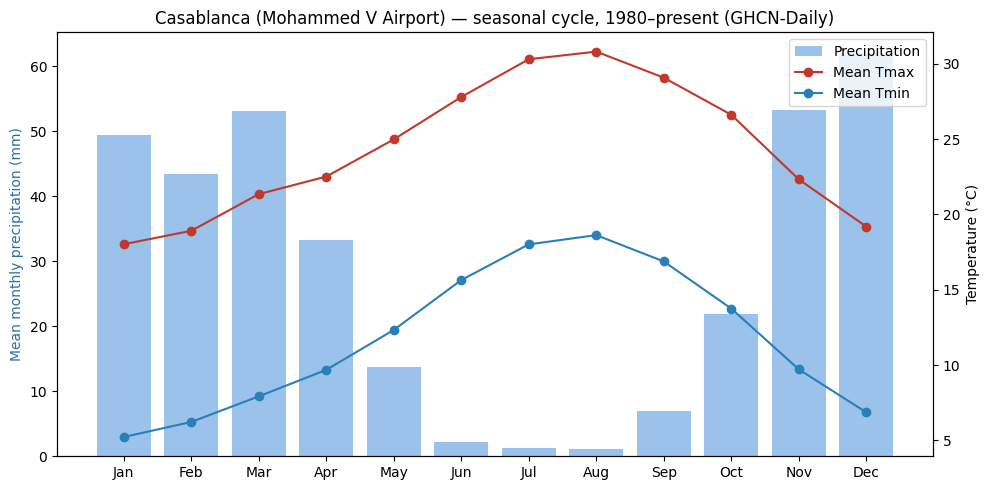

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

monthly = wide.groupby(wide.index.month).mean()
labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
days = np.array([31, 28.25, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
monthly_total_mm = monthly["PRCP"].values * days     # climatological monthly accumulation

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(monthly.index, monthly_total_mm, color="#4a90d9", alpha=0.55, label="Precipitation")
ax1.set_ylabel("Mean monthly precipitation (mm)", color="#2e6da4")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(labels)

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["TMAX"], "-o", color="#c0392b", label="Mean Tmax")
ax2.plot(monthly.index, monthly["TMIN"], "-o", color="#2980b9", label="Mean Tmin")
ax2.set_ylabel("Temperature (°C)")

ax1.set_title("Casablanca (Mohammed V Airport) — seasonal cycle, 1980–present (GHCN-Daily)")
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labs = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labs, loc="upper right")
plt.tight_layout()
plt.show()

## 4 — The warming trend since 1980

**English.** Now the headline: how has Casablanca's temperature changed since
1980? We take the annual mean of `TAVG`, keep only years with at least 250 valid
days (so a half-empty year can't skew the curve), and fit a straight line. The
slope, expressed in **°C per decade**, is the warming rate.

**Français.** Le point clé : comment la température de Casablanca a-t-elle évolué
depuis 1980 ? On calcule la moyenne annuelle de `TAVG`, on ne garde que les
années comptant au moins 250 jours valides (pour qu'une année à moitié vide ne
biaise pas la courbe), et on ajuste une droite. La pente, exprimée en **°C par
décennie**, donne le rythme du réchauffement.

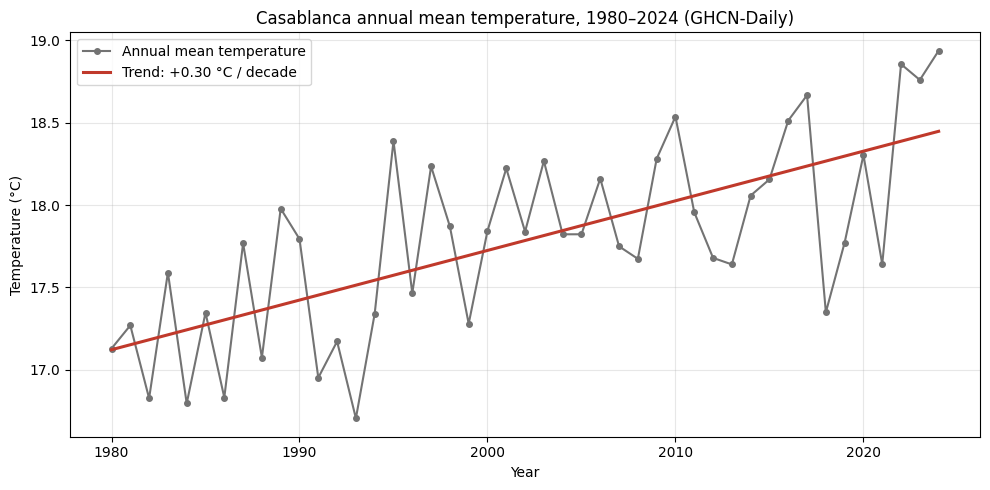

In [5]:
tavg = wide["TAVG"].dropna()
annual = tavg.resample("YS").mean()
counts = tavg.resample("YS").count()
annual = annual[counts >= 250]                       # well-sampled years only

years = annual.index.year.values
vals = annual.values
slope, intercept = np.polyfit(years, vals, 1)        # linear trend

plt.figure(figsize=(10, 5))
plt.plot(years, vals, "-o", color="0.45", ms=4, label="Annual mean temperature")
plt.plot(years, slope * years + intercept, "-", color="#c0392b", lw=2.2,
         label=f"Trend: {slope * 10:+.2f} °C / decade")
plt.title(f"Casablanca annual mean temperature, {years.min()}–{years.max()} (GHCN-Daily)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Year")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5 — Year-to-year rainfall and recent drought

**English.** Annual rainfall totals. Bars below the long-term mean (in red) are
dry years; a bar is drawn only for years with **≥250 valid precipitation days**.

> **Why some years are blank.** Missing bars are *not* zero-rain years — they are
> years this station under-reported to GHCN. Casablanca / Mohammed V Airport
> records precipitation completely through **1998**, then only intermittently;
> notably, several recent drought years (2019–2022) are largely unreported *at
> this station* and so drop out. Daily **temperature**, by contrast, is
> near-complete, so the warming trend above is robust. (A nearby station such as
> Casablanca-Anfa `MOM00060155` covers some of these recent gaps — combining
> stations is one way to fill them.)

**Français.** Cumuls annuels de pluie. Les barres sous la moyenne de long terme
(en rouge) sont des années sèches ; une barre n'est tracée que pour les années
comptant **≥250 jours de précipitations valides**.

> **Pourquoi certaines années sont vides.** Les barres manquantes ne sont *pas*
> des années sans pluie — ce sont des années où la station a sous-déclaré à GHCN.
> Casablanca / Aéroport Mohammed V relève les précipitations de façon complète
> jusqu'en **1998**, puis seulement par intermittence ; en particulier, plusieurs
> années de sécheresse récentes (2019–2022) sont largement non déclarées *à cette
> station* et disparaissent donc. La **température** quotidienne, en revanche, est
> quasi complète, d'où la robustesse de la tendance au réchauffement ci-dessus.
> (Une station voisine comme Casablanca-Anfa `MOM00060155` couvre certaines de
> ces lacunes — combiner les stations est une façon de les combler.)

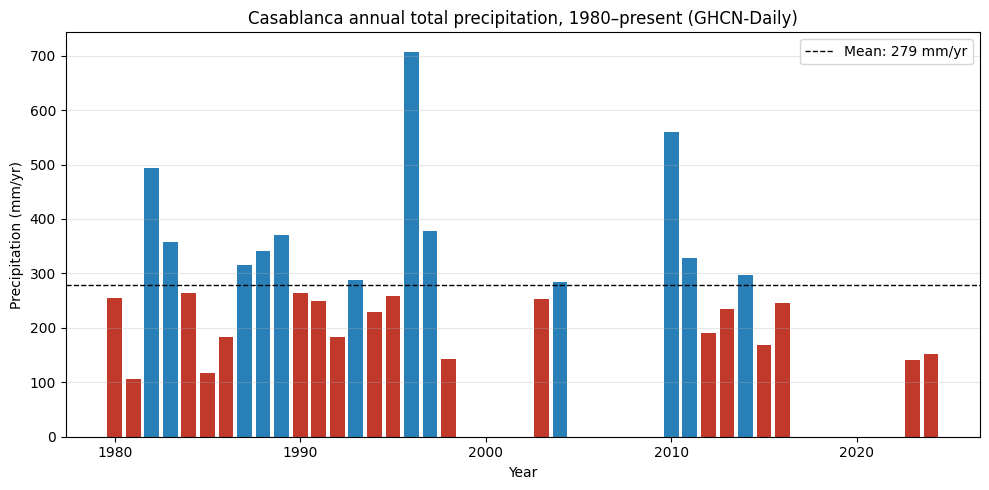

In [6]:
prcp = wide["PRCP"].dropna()
annual_p = prcp.resample("YS").sum()
pcount = prcp.resample("YS").count()
annual_p = annual_p[pcount >= 250]                   # well-sampled years only
mean_p = annual_p.mean()

colors = ["#c0392b" if v < mean_p else "#2980b9" for v in annual_p.values]
plt.figure(figsize=(10, 5))
plt.bar(annual_p.index.year, annual_p.values, color=colors)
plt.axhline(mean_p, color="k", ls="--", lw=1, label=f"Mean: {mean_p:.0f} mm/yr")
plt.title("Casablanca annual total precipitation, 1980–present (GHCN-Daily)")
plt.ylabel("Precipitation (mm/yr)")
plt.xlabel("Year")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Going further · Pour aller plus loin

**English**
- Swap `STATION` for another GHCN-Daily site. The station list (IDs, names,
  lat/lon, country) is at
  `https://noaa-ghcn-pds.s3.amazonaws.com/ghcnd-stations.txt`; Moroccan IDs start
  with `MO`, `MOM`, `MOE`, `MOW`. Element/year coverage is in `ghcnd-inventory.txt`.
- Change the start year (`wide.loc["1980":]`) to use the full record back to the
  1940s, or compare this station series with the ERA5 and IMERG notebooks at the
  same point — reanalysis vs satellite vs ground truth.
- Watch for data gaps and station moves; `Q_FLAG`/`M_FLAG` document quality and
  measurement details.

**Français**
- Remplacez `STATION` par une autre station GHCN-Daily. La liste (ID, noms,
  lat/lon, pays) est dans
  `https://noaa-ghcn-pds.s3.amazonaws.com/ghcnd-stations.txt` ; les ID marocains
  commencent par `MO`, `MOM`, `MOE`, `MOW`. La couverture éléments/années est
  dans `ghcnd-inventory.txt`.
- Modifiez l'année de début (`wide.loc["1980":]`) pour utiliser tout
  l'enregistrement jusqu'aux années 1940, ou comparez cette série de station aux
  notebooks ERA5 et IMERG au même point — réanalyse vs satellite vs vérité terrain.
- Attention aux lacunes et aux déménagements de station ; `Q_FLAG`/`M_FLAG`
  documentent la qualité et les détails de mesure.

**References / Références**
- AWS Open Data: https://registry.opendata.aws/noaa-ghcn/
- GHCN-Daily: https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily
- Station inventory: https://noaa-ghcn-pds.s3.amazonaws.com/ghcnd-stations.txt